In [1]:
import os
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

OASIS_DIR = "../../data/oasis"

# encoding="latin1" is required here — the OASIS CSV contains non-UTF-8 characters
# that cause a UnicodeDecodeError under the default utf-8 encoding.
labels = pd.read_csv(os.path.join(OASIS_DIR, "oasis_cross-sectional.csv"), encoding="latin1")

print("First 5 subjects:")
print(labels.head())

print("\nCDR value counts (0 = Nondemented, 0.5/1/2 = Demented, NaN = no diagnosis on record):")
print(labels["CDR"].value_counts(dropna=False))

First 5 subjects:
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  

CDR value counts (0 = Nondemented, 0.5/1/2 = Demented, NaN = no diagnosis on record):
CDR
NaN    201
0.0    135
0.5     70
1.0     28
2.0      2
Name: count, dtype: int64


In [ ]:
# Build one master index mapping every subject, across all 12 discs, to its scan file
# and clinical label — instead of hardcoding a path to a single disc/subject.
# Each subject has repeated acquisitions mpr-1 through mpr-4; we use mpr-1 as the
# primary scan for each subject.

DISCS = [f"disc{i}" for i in range(1, 13)]
records = []

for disc in DISCS:
    disc_path = os.path.join(OASIS_DIR, disc)
    if not os.path.isdir(disc_path):
        continue
    for subject_id in os.listdir(disc_path):
        subject_path = os.path.join(disc_path, subject_id)
        if not os.path.isdir(subject_path) or not subject_id.startswith("OAS1_"):
            continue
        raw_dir = os.path.join(subject_path, "RAW")
        if not os.path.isdir(raw_dir):
            continue
        hdr_path = os.path.join(raw_dir, f"{subject_id}_mpr-1_anon.hdr")
        if os.path.exists(hdr_path):
            records.append({"ID": subject_id, "disc": disc, "scan_path": hdr_path})

scan_index = pd.DataFrame(records)
print(f"Found {len(scan_index)} subjects with a usable mpr-1 scan across all 12 discs")

# Merge scan locations with clinical labels on subject ID
merged = scan_index.merge(labels, on="ID", how="left")

print(f"\nMerged dataset: {len(merged)} rows")
print(f"Subjects with a CDR value: {merged['CDR'].notna().sum()}")
print(f"Subjects with missing CDR: {merged['CDR'].isna().sum()}")

# Save this intermediate index so it never needs to be rebuilt from raw discs again
merged.to_csv(os.path.join(OASIS_DIR, "oasis_master_index.csv"), index=False)
print("\nSaved to data/oasis/oasis_master_index.csv")

Found 436 subjects with a usable mpr-1 scan across all 12 discs

Merged dataset: 436 rows
Subjects with a CDR value: 235
Subjects with missing CDR: 201

Saved to data/oasis/oasis_master_index.csv


Loading sample scan for subject OAS1_0016_MR1 (CDR = 0.5)
Volume shape after squeeze: (256, 256, 128)


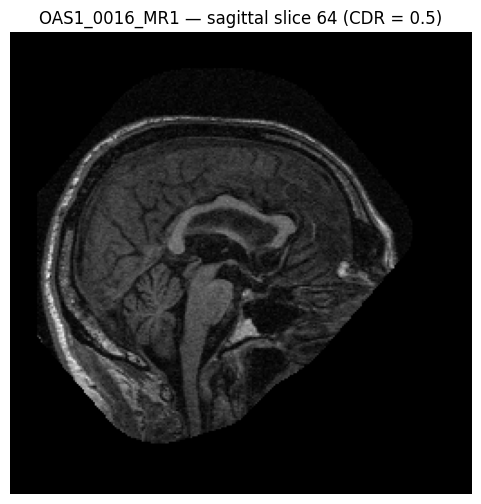

In [3]:
# Sanity check: load the first scan in our index (via the index, not a hardcoded path)
# to confirm the full pipeline — CSV, index, and scan loading — works end to end.

sample = merged.iloc[0]
print(f"Loading sample scan for subject {sample['ID']} (CDR = {sample['CDR']})")

img = nib.load(sample["scan_path"])
data = img.get_fdata().squeeze()  # drop the singleton 4th dimension: (256, 256, 128, 1) -> (256, 256, 128)

print("Volume shape after squeeze:", data.shape)

# Note: this is a sagittal volume (side-view slices), not axial — OASIS's raw Analyze
# format stores the third axis as the sagittal direction. This is a standard, commonly
# used view in 2D Alzheimer's classification work since it shows the corpus callosum
# and ventricles clearly.
mid_slice = data.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
plt.title(f"{sample['ID']} — sagittal slice {mid_slice} (CDR = {sample['CDR']})")
plt.axis("off")
plt.show()

In [ ]:
# Keep only subjects with a recorded CDR — subjects with missing CDR cannot be used
# for training since there is no label to learn from.
model_df = merged[merged["CDR"].notna()].copy()

# Standard binary label convention used in most OASIS classification papers:
# CDR = 0        -> Nondemented (0)
# CDR > 0 (0.5/1/2) -> Demented (1)
#
# Alternative worth knowing about: some papers exclude CDR 0.5 entirely as a genuinely
# ambiguous borderline case, training only on clearly-0 vs clearly-1+. Not applied here,
model_df["label"] = (model_df["CDR"] > 0).astype(int)

print("Final label distribution:")
print(model_df["label"].value_counts())


model_df.to_csv(os.path.join(OASIS_DIR, "oasis_model_ready.csv"), index=False)


Final label distribution:
label
0    135
1    100
Name: count, dtype: int64
